In [2]:
from datasets import load_dataset

ds = load_dataset("thethinkmachine/tiny-imagenet")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
ds.shape

{'train': (100000, 2), 'valid': (10000, 2)}

In [5]:
batch = ds["train"].features
class_names = batch["label"].names
len(class_names)

200

In [6]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [7]:
def train_transforms(batch):
    batch["image"] = [train_transform(img) for img in batch["image"]]
    return batch

def val_transforms(batch):
    batch["image"] = [val_transform(img) for img in batch["image"]]
    return batch

ds["train"].set_transform(train_transforms)
ds["valid"].set_transform(val_transforms)

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(ds["train"],
                          batch_size=32,
                          shuffle=True,
                          num_workers=4,
                          pin_memory=False)

val_loader = DataLoader(ds["valid"],
                        batch_size=32,
                        num_workers=4,
                        shuffle=True,
                        pin_memory=False)

In [9]:
batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

images.shape, labels.shape, labels

(torch.Size([32, 3, 224, 224]),
 torch.Size([32]),
 tensor([195,  26, 175,  73, 172, 191, 136, 130, 184,  35,  27,  19, 188, 153,
           6,  70, 156, 100, 115, 179, 122, 191, 104, 107,  52,  81, 135, 123,
          42, 164,  84, 104]))

In [10]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

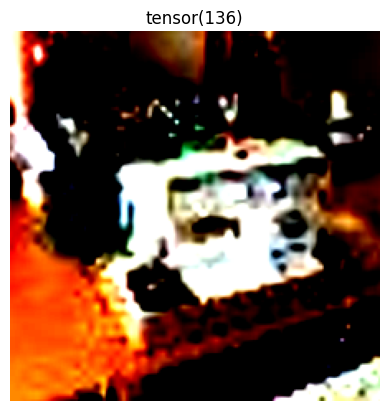

In [11]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(images), size=[1]).item()
img, label = images[random_idx], labels[random_idx]
plt.imshow(img.squeeze().permute(1,2,0), cmap="gray")
plt.title(label)
plt.axis(False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.2710083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.3585434].
C

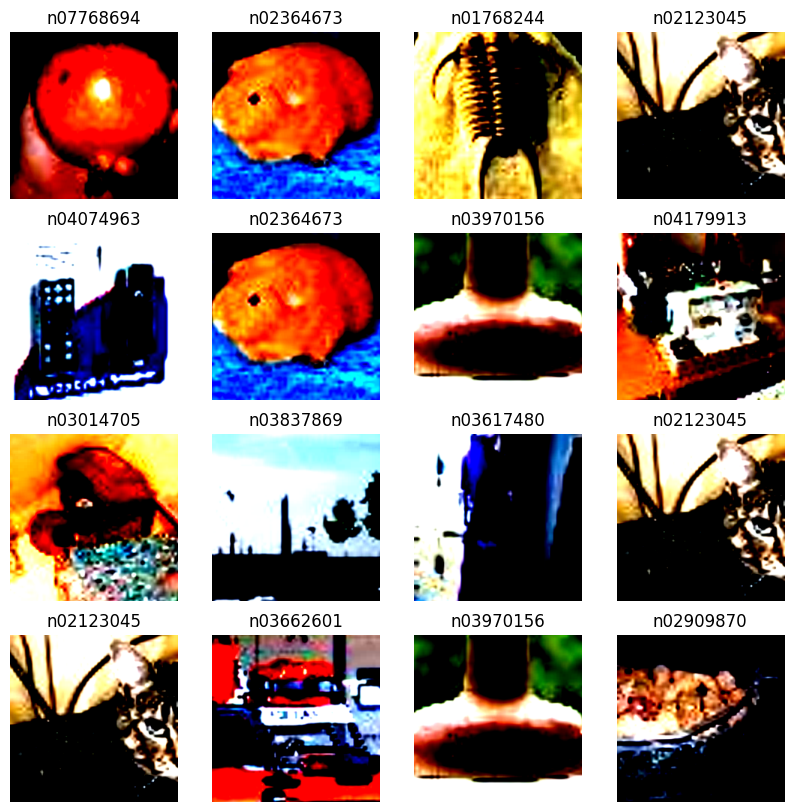

In [12]:
fig = plt.figure(figsize=(10,10))
rows, cols = 4, 4

for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(images), size=[1]).item()
    image, label = images[random_idx], labels[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze().permute(1,2,0))
    plt.title(class_names[label])
    plt.axis(False)

In [13]:
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [16]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_0 = AlexNet(num_classes=200).to(device)
model_0

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, 

In [17]:
dummy = torch.rand([32, 3, 224, 224])
print(f"{model_0(dummy).squeeze()} -> logits")

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [36]:
def accuracy_fn(y_true, y_pred):
    preds = torch.argmax(y_pred, dim=1)
    correct = (preds == y_true).sum().item()
    return correct / y_true.size(0)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model_0.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4
)

In [37]:
from tqdm.auto import tqdm
import torch

epochs = 100

model_0.train()

loss_count = []
epoch_count = []

for epoch in range(epochs):
    running_loss = 0.0

    for step, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
        images = batch["image"].cuda(non_blocking=True)
        labels = batch["label"].cuda(non_blocking=True)

        optimizer.zero_grad()

        outputs = model_0(images)
        loss = loss_fn(outputs, labels)
        loss_count.append(loss)
        epoch_count.append(epoch)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch} | Loss {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch} finished | Avg loss: {epoch_loss:.4f}")

model_0.eval()
val_loss = 0.0
val_acc = 0.0

with torch.inference_mode():
    for batch in tqdm(val_loader, total=len(val_loader)):
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        outputs = model_0(images)
        loss = loss_fn(outputs, labels)

        val_loss += loss.item()
        val_acc += accuracy_fn(labels, outputs)

val_loss /= len(val_loader)
val_acc /= len(val_loader)

print(
    f"Epoch {epoch} | "
    f"Train loss: {epoch_loss:.4f} | "
    f"Val loss: {val_loss:.4f} | "
    f"Val acc: {val_acc:.4f}"
)




100%|██████████| 3125/3125 [02:41<00:00, 19.29it/s]

Epoch 0 | Loss nan
Epoch 0 finished | Avg loss: nan



100%|██████████| 3125/3125 [02:41<00:00, 19.35it/s]

Epoch 1 | Loss nan
Epoch 1 finished | Avg loss: nan



100%|██████████| 3125/3125 [02:41<00:00, 19.36it/s]

Epoch 2 | Loss nan
Epoch 2 finished | Avg loss: nan



100%|██████████| 3125/3125 [02:42<00:00, 19.28it/s]

Epoch 3 | Loss nan
Epoch 3 finished | Avg loss: nan



 18%|█▊        | 565/3125 [00:29<02:14, 19.07it/s]


KeyboardInterrupt: 

In [34]:
loss_count = [l.cpu().item() for l in loss_count]
type(loss_count), type(loss_count[0])

(list, float)

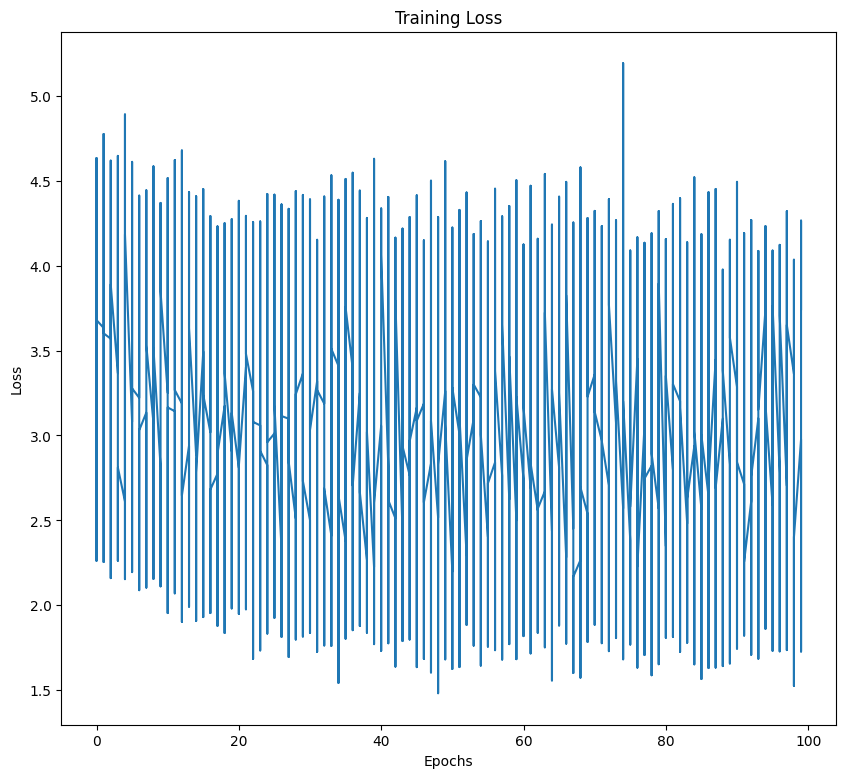

In [35]:
plt.figure(figsize=(10,9))
plt.plot(epoch_count, loss_count)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()